In [ ]:
# ==== RISK_DATA_v5 – Cell 1: Download data, build features, per-stock frames ====

import numpy as np
import pandas as pd
import yfinance as yf
from tqdm import tqdm

# ----------------------------
# Config
# ----------------------------
START_DATE = "2005-01-01"
END_DATE   = "2025-01-01"

# Index we use for "market pressure"
INDEX_TICKER = "^NSEI"   # Nifty 50

# You can replace/extend this with Nifty 500.
# Easiest: keep a CSV with a 'Symbol' column and read it here.
# For now I put a seed list – extend this to NIFTY 50/100/500 as needed.
SEED_TICKERS = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "AXISBANK.NS", "KOTAKBANK.NS",
    "SBIN.NS", "INFY.NS", "TCS.NS", "HINDUNILVR.NS", "LT.NS",
]

def load_nifty500_tickers_from_csv(path="nifty100_like_100_tickers.csv"):
    """
    Optional: read tickers from a CSV you upload.

    Accepts:
      - Column 'Symbol' like RELIANCE, TCS (will append .NS)
      - OR column 'ticker' like RELIANCE.NS, TCS.NS
      - OR first column if neither exists
    """
    try:
        df = pd.read_csv(path)

        if "ticker" in df.columns:
            vals = df["ticker"].astype(str).str.strip().tolist()
            tickers = []
            for v in vals:
                if not v or v.lower() == "nan":
                    continue
                tickers.append(v if v.endswith(".NS") or v.startswith("^") else v + ".NS")
            print(f"Loaded {len(tickers)} tickers from {path} (ticker column)")
            return tickers

        if "Symbol" in df.columns:
            syms = df["Symbol"].astype(str).str.strip().tolist()
            tickers = [s if s.endswith(".NS") else s + ".NS" for s in syms if s and s.lower() != "nan"]
            print(f"Loaded {len(tickers)} tickers from {path} (Symbol column)")
            return tickers

        # fallback: first column
        vals = df.iloc[:, 0].astype(str).str.strip().tolist()
        tickers = []
        for v in vals:
            if not v or v.lower() == "nan":
                continue
            tickers.append(v if v.endswith(".NS") or v.startswith("^") else v + ".NS")
        print(f"Loaded {len(tickers)} tickers from {path} (first column)")
        return tickers

    except Exception as e:
        print(f"Could not load {path}: {e}")
        print("Using SEED_TICKERS instead.")
        return SEED_TICKERS


# CHOOSE: either use CSV or the seed list
TICKERS = load_nifty500_tickers_from_csv()  # or: TICKERS = SEED_TICKERS

# ----------------------------
# Helper functions
# ----------------------------

def _flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    yfinance may return MultiIndex columns (or tuples).
    Convert them into plain strings so downstream renaming never crashes.
    """
    if df is None or df.empty:
        return df

    # MultiIndex columns
    if hasattr(df.columns, "nlevels") and getattr(df.columns, "nlevels", 1) > 1:
        df = df.copy()
        df.columns = [
            "_".join([str(x) for x in col if x not in (None, "", " ")])
            for col in df.columns
        ]
        return df

    # Tuple columns
    df = df.copy()
    new_cols = []
    for c in df.columns:
        if isinstance(c, tuple):
            new_cols.append("_".join(map(str, c)))
        else:
            new_cols.append(str(c))
    df.columns = new_cols
    return df


def download_ohlcv(ticker, start=START_DATE, end=END_DATE):
    """Download OHLCV from yfinance and standardize column names."""
    df = yf.download(
        ticker,
        start=start,
        end=end,
        progress=False,
        auto_adjust=False,
        group_by="column"
    )
    if df is None or df.empty:
        return pd.DataFrame()

    # Flatten tuple/MultiIndex columns to strings
    df = _flatten_yf_columns(df)

    # --- FIX: normalize columns like "Open_^NSEI" -> "open" ---
    def normalize_col(c: str) -> str:
        s = str(c).strip().lower()

        # If we got "open_^nsei" / "close_reliance.ns" etc., keep only the left part
        # before the first underscore.
        base = s.split("_", 1)[0]

        # Some variants can appear
        base = base.replace("adj close", "adj_close").replace("adjclose", "adj_close")

        return base

    df = df.rename(columns={c: normalize_col(c) for c in df.columns})

    # If both close + adj_close exist, prefer close (or keep both if you want)
    # Here we keep just close as before.
    if "adj_close" in df.columns and "close" not in df.columns:
        df["close"] = df["adj_close"]

    needed = ["open", "high", "low", "close", "volume"]
    missing = [n for n in needed if n not in df.columns]
    if missing:
        print(f"[WARN] {ticker}: missing cols {missing}, skipping.")
        return pd.DataFrame()

    df = df[needed].copy()
    df.index.name = "date"
    return df


def add_stock_features(df):
    """
    Add price-based features similar to base paper, causally:
    - logret (daily log return)
    - MA10, MA50, MA100 of close
    - volatility windows
    - volume z-score
    - trend_10_50 (short vs medium MA)
    """
    df = df.copy()
    df["logret"] = np.log(df["close"] / df["close"].shift(1))

    df["ma10"] = df["close"].rolling(10).mean()
    df["ma50"] = df["close"].rolling(50).mean()
    df["ma100"] = df["close"].rolling(100).mean()

    df["vol_10"] = df["logret"].rolling(10).std()
    df["vol_20"] = df["logret"].rolling(20).std()
    df["vol_60"] = df["logret"].rolling(60).std()

    vol_ma = df["volume"].rolling(20).mean()
    vol_std = df["volume"].rolling(20).std()
    df["volume_z"] = (df["volume"] - vol_ma) / vol_std

    # Short vs medium term trend (like "MA for 10 vs 50 days")
    df["trend_10_50"] = (df["ma10"] - df["ma50"]) / df["ma50"]

    # Drop initial NaNs
    df = df.dropna()
    return df


def add_index_features(index_ticker=INDEX_TICKER):
    """Build index features: daily log return + 10-day volatility."""
    idx_df = download_ohlcv(index_ticker)
    if idx_df.empty:
        raise ValueError("Index download failed.")

    idx_df["logret"] = np.log(idx_df["close"] / idx_df["close"].shift(1))
    idx_df["vol_10"] = idx_df["logret"].rolling(10).std()
    idx_df = idx_df.dropna()
    idx_df = idx_df.rename(
        columns={
            "logret": "idx_logret_1d",
            "vol_10": "idx_vol_10",
        }
    )
    return idx_df[["idx_logret_1d", "idx_vol_10"]]


def build_per_stock_frames(
    tickers,
    big_move_quantile=0.9,
    min_len=300,
):
    """
    For each ticker:
    - download OHLCV
    - add stock features
    - merge index features
    - compute logret_next and global big_move_next label
    Returns:
      stock_frames: dict[ticker] -> DataFrame(features + big_move_next)
      big_move_thr: scalar threshold used for |logret_next|
    """
    idx_feat = add_index_features()

    frames = {}
    all_logret_next = []

    for ticker in tqdm(tickers):
        base = download_ohlcv(ticker)
        if base.empty or len(base) < min_len:
            continue

        feat = add_stock_features(base)
        merged = feat.join(idx_feat, how="inner")
        if merged.empty or len(merged) < min_len:
            continue

        # Forward log return (next day) for the LABEL
        merged["logret_next"] = merged["logret"].shift(-1)

        # Drop last row where logret_next is NaN
        merged = merged.dropna(subset=["logret_next"])

        if len(merged) < min_len:
            continue

        frames[ticker] = merged
        all_logret_next.append(merged["logret_next"])

    if not frames:
        raise ValueError("No valid stocks downloaded. Check tickers/date range.")

    all_logret_next = pd.concat(all_logret_next)
    big_thr = all_logret_next.abs().quantile(big_move_quantile)
    print(f"Global big-move threshold (|logret_next|): {big_thr:.6f}")

    # Now assign labels per stock
    for ticker, df in frames.items():
        df["big_move_next"] = (df["logret_next"].abs() >= big_thr).astype(int)

    return frames, big_thr


# ---- Run Cell 1 ----
stock_frames, global_big_move_thr = build_per_stock_frames(TICKERS)

print(f"Built per-stock frames for {len(stock_frames)} tickers.")
for t, df in list(stock_frames.items())[:3]:
    pos_rate = df["big_move_next"].mean()
    print(f"{t}: rows={len(df)}, big-move rate={pos_rate:.3f}")


Loaded 100 tickers from nifty100_like_100_tickers.csv (ticker column)


 23%|██▎       | 23/100 [00:04<00:19,  3.99it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')
 75%|███████▌  | 75/100 [00:16<00:04,  5.36it/s]ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ZOMATO.NS']: YFTzMissingError('possibly delisted; no timezone found')
100%|██████████| 100/100 [00:22<00:00,  4.44it/s]

Global big-move threshold (|logret_next|): 0.033886
Built per-stock frames for 97 tickers.
RELIANCE.NS: rows=4227, big-move rate=0.074
TCS.NS: rows=4227, big-move rate=0.064
HDFCBANK.NS: rows=4227, big-move rate=0.059


In [ ]:
# ==== RISK_DATA_v5 – Cell 2 (RAM efficient): streaming windows + scaler + repeat + steps ====

import math
import numpy as np
import tensorflow as tf

# Safety check
if "stock_frames" not in globals() or not isinstance(stock_frames, dict) or len(stock_frames) == 0:
    raise RuntimeError("stock_frames is not available. Please run Cell 1 first to build stock_frames.")

# Window length
T = 120

FEATURE_COLS = [
    "logret",
    "ma10", "ma50", "ma100",
    "vol_10", "vol_20", "vol_60",
    "volume_z",
    "trend_10_50",
    "idx_logret_1d",
    "idx_vol_10",
]
LABEL_COL = "big_move_next"

BATCH_SIZE = 256
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

F = len(FEATURE_COLS)

# -------------------------
# Window iterators
# -------------------------
def iter_windows_for_stock(df, split: str, T=T, feature_cols=FEATURE_COLS, label_col=LABEL_COL):
    feats = df[feature_cols].to_numpy(dtype=np.float32, copy=False)
    labels = df[label_col].to_numpy(dtype=np.int8, copy=False)

    n = len(df)
    if n <= T + 1:
        return

    # label index i ranges [T, n-1]
    i_start = T
    i_end = n
    total = i_end - i_start

    tr_end = i_start + int(total * TRAIN_FRAC)
    va_end = tr_end + int(total * VAL_FRAC)

    if split == "train":
        lo, hi = i_start, tr_end
    elif split == "val":
        lo, hi = tr_end, va_end
    elif split == "test":
        lo, hi = va_end, i_end
    else:
        raise ValueError("split must be train/val/test")

    for i in range(lo, hi):
        X = feats[i - T:i]   # (T, F)
        y = labels[i]        # scalar
        yield X, y


def iter_windows_all_stocks(stock_frames, split: str):
    for _t, df in stock_frames.items():
        yield from iter_windows_for_stock(df, split=split)


# -------------------------
# Streaming scaler (Welford)
# -------------------------
class StreamingStandardizer:
    def __init__(self, F):
        self.F = F
        self.count = 0
        self.mean = np.zeros(F, dtype=np.float64)
        self.M2 = np.zeros(F, dtype=np.float64)

    def update_batch(self, X_2d):
        X = X_2d.astype(np.float64, copy=False)
        for x in X:
            self.count += 1
            delta = x - self.mean
            self.mean += delta / self.count
            delta2 = x - self.mean
            self.M2 += delta * delta2

    def finalize(self):
        var = self.M2 / max(self.count - 1, 1)
        std = np.sqrt(var)
        std[std == 0] = 1.0
        return self.mean.astype(np.float32), std.astype(np.float32)


print("Computing scaler stats from TRAIN split (streaming, RAM-safe)...")
scaler = StreamingStandardizer(F)

chunk = []
CHUNK_WINDOWS = 64  # 64 windows * 120 rows = 7680 rows per update

for X, _y in iter_windows_all_stocks(stock_frames, split="train"):
    chunk.append(X)
    if len(chunk) >= CHUNK_WINDOWS:
        Xc = np.concatenate(chunk, axis=0)  # (CHUNK_WINDOWS*T, F)
        scaler.update_batch(Xc)
        chunk = []

if chunk:
    Xc = np.concatenate(chunk, axis=0)
    scaler.update_batch(Xc)

mean, std = scaler.finalize()
print("Scaler fitted. count rows:", scaler.count)


# -------------------------
# tf.data dataset builder
# -------------------------
def make_tf_dataset(stock_frames, split: str, mean, std, batch_size=BATCH_SIZE, shuffle=False):
    output_signature = (
        tf.TensorSpec(shape=(T, F), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int8),
    )

    def gen():
        for X, y in iter_windows_all_stocks(stock_frames, split=split):
            Xs = (X - mean) / std
            yield Xs, y

    ds = tf.data.Dataset.from_generator(gen, output_signature=output_signature)

    if shuffle:
        ds = ds.shuffle(20000, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Finite datasets (one pass)
train_ds = make_tf_dataset(stock_frames, "train", mean, std, shuffle=True)
val_ds   = make_tf_dataset(stock_frames, "val",   mean, std, shuffle=False)
test_ds  = make_tf_dataset(stock_frames, "test",  mean, std, shuffle=False)


# -------------------------
# Count windows to set steps/epoch
# -------------------------
def count_windows(stock_frames, split: str, T=T):
    total = 0
    for _t, df in stock_frames.items():
        n = len(df)
        if n <= T + 1:
            continue

        i_start = T
        i_end = n
        tot = i_end - i_start
        tr_end = i_start + int(tot * TRAIN_FRAC)
        va_end = tr_end + int(tot * VAL_FRAC)

        if split == "train":
            total += max(0, tr_end - i_start)
        elif split == "val":
            total += max(0, va_end - tr_end)
        elif split == "test":
            total += max(0, i_end - va_end)
        else:
            raise ValueError("split must be train/val/test")
    return total


train_windows = count_windows(stock_frames, "train")
val_windows   = count_windows(stock_frames, "val")
test_windows  = count_windows(stock_frames, "test")

train_steps = math.ceil(train_windows / BATCH_SIZE)
val_steps   = math.ceil(val_windows / BATCH_SIZE)
test_steps  = math.ceil(test_windows / BATCH_SIZE)

print("Windows:", train_windows, val_windows, test_windows)
print("Steps  :", train_steps, val_steps, test_steps)


# -------------------------
# Repeat datasets to avoid "ran out of data"
# -------------------------
train_ds = train_ds.repeat()
val_ds   = val_ds.repeat()
test_ds  = test_ds.repeat()

print("Datasets ready (repeating).")
xb, yb = next(iter(train_ds))
print("Batch X:", xb.shape, xb.dtype, "| Batch y:", yb.shape, yb.dtype,
      "| Pos rate (batch):", tf.reduce_mean(tf.cast(yb, tf.float32)).numpy())


Computing scaler stats from TRAIN split (streaming, RAM-safe)...
Scaler fitted. count rows: 29286960
Windows: 244058 52300 52405
Steps  : 954 205 205
Datasets ready (repeating).
Batch X: (256, 120, 11) <dtype: 'float32'> | Batch y: (256,) <dtype: 'int8'> | Pos rate (batch): 0.0703125


In [ ]:
# ==== RISK_MSF_v5 – Cell 3: Ablation training (Baseline LSTM vs MSF-CAL-ish) ====

import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

tf.keras.backend.clear_session()
print("TF version:", tf.__version__)

# --- Safety checks ---
required = ["train_ds", "val_ds", "test_ds", "train_steps", "val_steps", "test_steps"]
for name in required:
    if name not in globals():
        raise RuntimeError(f"{name} not found. Run Cell 2 (repeat+steps version) first.")

# Infer input shape
xb, yb = next(iter(train_ds))
T, F = int(xb.shape[1]), int(xb.shape[2])
input_shape = (T, F)
print("Input shape:", input_shape)

# -------------------------
# Models
# -------------------------
def build_lstm_model(input_shape, l2=1e-4, dropout=0.2):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(32, kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="baseline_lstm")


class AttentionPooling(layers.Layer):
    """Attention pooling over time: (B,T,H)->(B,H)"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score = layers.Dense(1)

    def call(self, x):
        scores = self.score(x)               # (B,T,1)
        weights = tf.nn.softmax(scores, 1)   # (B,T,1)
        return tf.reduce_sum(weights * x, 1) # (B,H)


def build_msfcal_model(
    input_shape,
    l2=1e-4,
    dropout=0.25,
    conv_filters=32,
    lstm_units=64,
    use_attention=True,
):
    inp = layers.Input(shape=input_shape)
    x0 = layers.LayerNormalization()(inp)

    branches = []
    for k in (3, 5, 7):
        b = layers.Conv1D(conv_filters, kernel_size=k, padding="same",
                          activation="relu",
                          kernel_regularizer=regularizers.l2(l2))(x0)
        b = layers.Dropout(dropout)(b)
        branches.append(b)

    x = layers.Concatenate()(branches)  # (B,T,conv_filters*3)

    x = layers.Conv1D(conv_filters, kernel_size=1, padding="same",
                      activation="relu",
                      kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, kernel_regularizer=regularizers.l2(l2))
    )(x)
    x = layers.Dropout(dropout)(x)

    if use_attention:
        x = AttentionPooling()(x)
    else:
        x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inp, out, name="msfcal")


def compile_model(m):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return m

# -------------------------
# Train + evaluate helper
# -------------------------
def train_and_eval(model, tag, epochs=30, save_dir="models"):
    os.makedirs(save_dir, exist_ok=True)
    compile_model(model)
    print("\n" + "="*80)
    print(f"Training: {tag}  |  Params: {model.count_params():,}")
    print("="*80)
    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=5, mode="max", restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", patience=2, mode="max", factor=0.5, min_lr=1e-5),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        steps_per_epoch=train_steps,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1
    )

    metrics = model.evaluate(test_ds, steps=test_steps, verbose=0)
    metrics_dict = dict(zip(model.metrics_names, metrics))

    # Save weights (small & fast)
    weights_path = os.path.join(save_dir, f"{tag}.weights.h5")
    model.save_weights(weights_path)

    return history, metrics_dict, weights_path


# -------------------------
# Run ablation: train both
# -------------------------
results = []

# 1) Baseline LSTM
lstm_model = build_lstm_model(input_shape)
hist_lstm, test_lstm, w_lstm = train_and_eval(lstm_model, "baseline_lstm")

results.append({
    "model": "baseline_lstm",
    "params": lstm_model.count_params(),
    **test_lstm,
    "weights": w_lstm
})

# Clear session between models to reduce memory fragmentation
tf.keras.backend.clear_session()

# Need to re-grab ds iterator batch shape after clear_session? not required; ds lives outside TF graph.
# 2) MSF-CAL-ish
msf_model = build_msfcal_model(input_shape)
hist_msf, test_msf, w_msf = train_and_eval(msf_model, "msfcal")

results.append({
    "model": "msfcal",
    "params": msf_model.count_params(),
    **test_msf,
    "weights": w_msf
})

# -------------------------
# Summary table
# -------------------------
df_results = pd.DataFrame(results)
# Make it readable
cols = ["model", "params"] + [c for c in df_results.columns if c not in ("model", "params")]
df_results = df_results[cols]
print("\n\nAblation results (TEST):")
display(df_results)


TF version: 2.19.0
Input shape: (120, 11)

Training: baseline_lstm  |  Params: 32,961


Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,961 (128.75 KB)

 Trainable params: 32,961 (128.75 KB)

...

 Total params: 66,616 (260.22 KB)

 Trainable params: 66,616 (260.22 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
954/954 ━━━━━━━━━━━━━━━━━━━━ 122s 115ms/step - auc: 0.6925 - loss: 0.3139 - precision: 0.0819 - recall: 0.0023 - val_auc: 0.7156 - val_loss: 0.3460 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
954/954 ━━━━━━━━━━━━━━━━━━━━ 109s 114ms/step - auc: 0.7300 - loss: 0.2832 - precision: 0.4522 - recall: 0.0047 - val_auc: 0.7178 - val_loss: 0.3411 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
954/954 ━━━━━━━━━━━━━━━━━━━━ 109s 114ms/step - auc: 0.7295 - loss: 0.2795 - precision: 0.5739 - recall: 0.0173 - val_auc: 0.7103 - val_loss: 0.3376 - val_precision: 0.7500 - val_recall: 0.0019 - learning_rate: 0.0010
Epoch 4/30
954/954 ━━━━━━━━━━━━━━━━━━━━ 109s 115ms/step - auc: 0.7328 - loss: 0.2773 - precision: 0.5893 - recall: 0.0250 - val_auc: 0.7141 - val_loss: 0.3367 - val_precision: 0.5714 - val_recall: 0.0013 - learning_rate: 0.0010
Epoch 5/30
954/954 ━━━━━━━━━━━━━━━━━━━━ 135s 141ms/step - auc: 0.7345 - 

,model,params,loss,compile_metrics,weights
0,baseline_lstm,32961,0.197858,0.693236,models/baseline_lstm.weights.h5
1,msfcal,66616,0.198411,0.696491,models/msfcal.weights.h5


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/architecture_baseline_lstm.png'

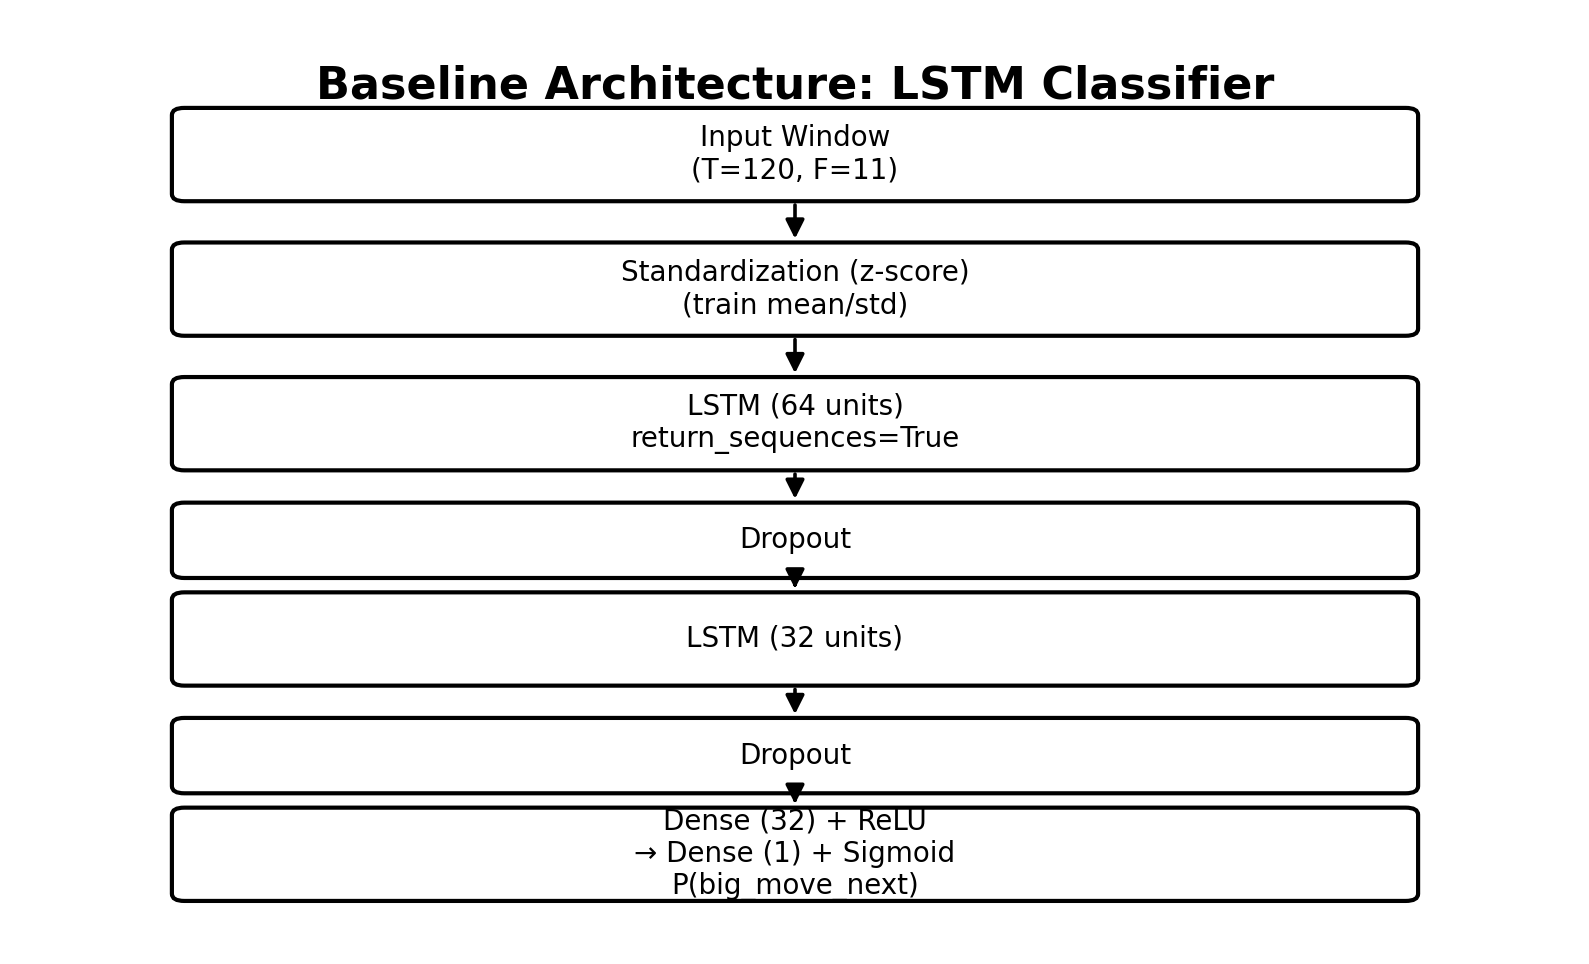

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib as mpl

def draw_flow(ax, title, boxes, arrows, xlim=(0, 10), ylim=(0, 10)):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.axis('off')
    ax.text((xlim[0]+xlim[1])/2, ylim[1]-0.5, title, ha='center', va='top', fontsize=16, fontweight='bold')
    # Draw boxes
    for b in boxes:
        x, y, w, h = b['xywh']
        patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                               linewidth=1.5, facecolor="white", edgecolor="black")
        ax.add_patch(patch)
        ax.text(x+w/2, y+h/2, b['text'], ha='center', va='center', fontsize=10)
    # Draw arrows
    for a in arrows:
        (x1, y1), (x2, y2) = a['start'], a['end']
        arr = FancyArrowPatch((x1, y1), (x2, y2),
                              arrowstyle='-|>', mutation_scale=14,
                              linewidth=1.3, color='black')
        ax.add_patch(arr)
        if 'label' in a and a['label']:
            lx, ly = a.get('label_pos', ((x1+x2)/2, (y1+y2)/2))
            ax.text(lx, ly, a['label'], ha='center', va='center', fontsize=9)

# -------- Baseline LSTM diagram ----------
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

baseline_boxes = [
    {'xywh': (1.0, 7.5, 8.0, 1.0), 'text': "Input Window\n(T=120, F=11)"},
    {'xywh': (1.0, 6.0, 8.0, 1.0), 'text': "Standardization (z-score)\n(train mean/std)"},
    {'xywh': (1.0, 4.5, 8.0, 1.0), 'text': "LSTM (64 units)\nreturn_sequences=True"},
    {'xywh': (1.0, 3.3, 8.0, 0.8), 'text': "Dropout"},
    {'xywh': (1.0, 2.1, 8.0, 1.0), 'text': "LSTM (32 units)"},
    {'xywh': (1.0, 0.9, 8.0, 0.8), 'text': "Dropout"},
    {'xywh': (1.0, -0.3, 8.0, 1.0), 'text': "Dense (32) + ReLU\n→ Dense (1) + Sigmoid\nP(big_move_next)"},
]
baseline_arrows = []
for i in range(len(baseline_boxes)-1):
    x, y, w, h = baseline_boxes[i]['xywh']
    x2, y2, w2, h2 = baseline_boxes[i+1]['xywh']
    baseline_arrows.append({'start': (x+w/2, y), 'end': (x2+w2/2, y2+h2)})

draw_flow(ax, "Baseline Architecture: LSTM Classifier", baseline_boxes, baseline_arrows, xlim=(0, 10), ylim=(-0.8, 9.5))
baseline_path = "/mnt/data/architecture_baseline_lstm.png"
fig.savefig(baseline_path, bbox_inches='tight')
plt.close(fig)

# -------- MSF-CAL-ish diagram ----------
fig, ax = plt.subplots(figsize=(12, 7), dpi=200)
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis('off')
ax.text(6, 9.6, "Proposed Architecture: MSF-CAL Inspired (Multi-scale + Attention)", ha='center', va='top',
        fontsize=16, fontweight='bold')

# Top input + norm
boxes = [
    {'xywh': (2.0, 8.1, 8.0, 1.0), 'text': "Input Window\n(T=120, F=11)"},
    {'xywh': (2.0, 6.8, 8.0, 1.0), 'text': "Layer Normalization"},
]

# Multi-scale branches
boxes += [
    {'xywh': (0.6, 5.1, 3.4, 1.2), 'text': "Conv1D k=3\n32 filters + ReLU\n+ Dropout"},
    {'xywh': (4.3, 5.1, 3.4, 1.2), 'text': "Conv1D k=5\n32 filters + ReLU\n+ Dropout"},
    {'xywh': (8.0, 5.1, 3.4, 1.2), 'text': "Conv1D k=7\n32 filters + ReLU\n+ Dropout"},
]

# Fuse + BiLSTM + attention + head
boxes += [
    {'xywh': (2.0, 3.6, 8.0, 1.0), 'text': "Concatenate (120×96)\n→ 1×1 Conv Fusion (32) + ReLU\n+ Dropout"},
    {'xywh': (2.0, 2.2, 8.0, 1.0), 'text': "BiLSTM (64 each direction)\nreturn_sequences=True → (120×128)\n+ Dropout"},
    {'xywh': (2.0, 0.9, 8.0, 1.0), 'text': "Attention Pooling\n(weighted sum over time) → (128)"},
    {'xywh': (2.0, -0.4, 8.0, 1.1), 'text': "Dense (64) + ReLU + Dropout\n→ Dense (1) + Sigmoid\nP(big_move_next)"},
]

# Arrows
arrows = []
# input -> norm
arrows.append({'start': (6, 8.1), 'end': (6, 7.8)})
arrows.append({'start': (6, 6.8), 'end': (6, 6.3)})

# norm -> branches (fan out)
arrows += [
    {'start': (6, 6.8), 'end': (2.3, 6.3)},
    {'start': (6, 6.8), 'end': (6.0, 6.3)},
    {'start': (6, 6.8), 'end': (9.7, 6.3)},
]

# branches -> concatenate
arrows += [
    {'start': (2.3, 5.1), 'end': (6, 4.6)},
    {'start': (6.0, 5.1), 'end': (6, 4.6)},
    {'start': (9.7, 5.1), 'end': (6, 4.6)},
]

# concatenate -> BiLSTM -> attention -> head
arrows += [
    {'start': (6, 3.6), 'end': (6, 3.2)},
    {'start': (6, 2.2), 'end': (6, 1.9)},
    {'start': (6, 0.9), 'end': (6, 0.6)},
]

# Draw
draw_flow(ax, "", boxes, arrows, xlim=(0, 12), ylim=(-0.8, 9.8))

# Add a subtle group label for multi-scale block
ax.text(6, 6.55, "Multi-scale Temporal Feature Extraction", ha='center', va='bottom', fontsize=10, fontweight='bold')

msf_path = "/mnt/data/architecture_msfcal.png"
fig.savefig(msf_path, bbox_inches='tight')
plt.close(fig)

(baseline_path, msf_path)

